In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for linar regression
from sklearn.linear_model import LinearRegression # machine learning model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error,r2_score


In [2]:
df = pd.read_csv('Data/Data/car_sales.csv')
df.head()

print(df['fuel'].unique())
fuel_id = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 3, 'Electric': 4}
df['fuel'] = df['fuel'].map(fuel_id)

print(df['seller_type'].unique())
seller_type_id = {'Individual': 0, 'Dealer': 1, 'Trustmark Dealer': 2}
df['seller_type_id'] = df['seller_type'].map(seller_type_id)

print(df['transmission'].unique())
transmission_id = {'Manual': 0, 'Automatic': 1}
df['transmission'] = df['transmission'].map(transmission_id)

print(df['owner'].unique())
owner_id = {
    'First Owner': 0,
    'Second Owner': 1,
    'Third Owner': 2,
    'Fourth & Above Owner': 3,
    'Test Drive Car': 4
}
df['owner_id'] = df['owner'].map(owner_id)

features = ['year', 'km_driven', 'fuel', 'seller_type_id', 'owner_id']
target = 'selling_price'

X = df[features]
Y = df[target]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)
  
  

<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)


In [10]:
from sklearn.metrics import mean_squared_error

#model accuracy
#mean squared error (ecludian distance)-> Actual rom where the prediction start
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)
print(f'root mean squared error:{rmse}')
print(f'R2 score(Accuracy):{r2}')
#rs score-> Accuracy number of how well model performs


root mean squared error:488130.4919977194
R2 score(Accuracy):0.2192182919410537


In [13]:
#for straight line
x_min,x_max=[Y_test.min(),Y_test.max()]#straight line horizontal
y_min,y_max=[Y_test.min(),Y_test.max()]# straight line vertical

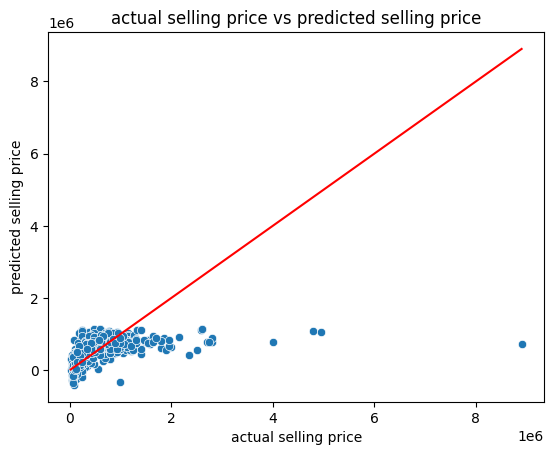

In [14]:
#visulization

#use of flatten is same a ravel. convert any dimension array into one dimension array.
#flatten used for machine learning visualization
sns.scatterplot(x=Y_test.values.flatten(),y=Y_pred.flatten())
plt.plot([x_min,x_max],[y_min,y_max],color='red')
plt.xlabel('actual selling price')
plt.ylabel("predicted selling price")
plt.title("actual selling price vs predicted selling price")
plt.show()

In [18]:
#random forest regressor
from sklearn.ensemble import RandomForestRegressor


In [19]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)
rf_pred= rf_model.predict(X_test)

In [20]:
rf_rmse=np.sqrt(mean_squared_error(Y_test,rf_pred))
rf_r2=r2_score(Y_test,rf_pred)
print(f'Random forest RMSE:{rf_rmse}')
print(f'Random forest R2 score (accuracy):{rf_r2}')


Random forest RMSE:468700.39941801014
Random forest R2 score (accuracy):0.2801394027145391


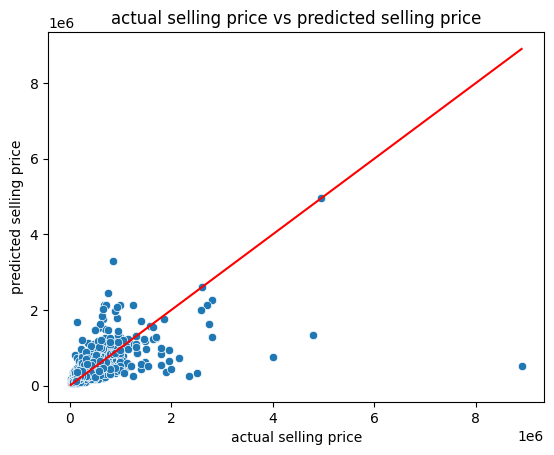

In [21]:
sns.scatterplot(x=Y_test.values.flatten(),y=rf_pred.flatten())
plt.plot([x_min,x_max],[y_min,y_max],color='red')
plt.xlabel('actual selling price')
plt.ylabel("predicted selling price")
plt.title("actual selling price vs predicted selling price")
plt.show()